In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Set seed
rng = np.random.default_rng(1050)

# Exercises in STK-IN1050 for week 20 (review)

### What this exercise set consists of:

- [A warm-up](#warm-up)
- [Exercise 1:](#exercise-1) Simulation
- [Exercise 2:](#exercise-2) Point estimation
- [Exercise 3:](#exercise-3) Permutation test

## A warm-up

Explain the terms "bias" and "variance" in your own words in relation to what you have learned in IN-STK1050 so far.

<span style="color: green;">**Possible solution:**</span>

Bias measures how far the expected value of an estimator is from the true parameter value:

$$
\operatorname{Bias}(\hat{\theta}) = E[\hat{\theta}] - \theta.
$$

Variance measures how much a random variable, or estimator, spreads around its own expected value:

$$
\operatorname{Var}(X) = E\left[(X - E[X])^2\right].
$$


## Exercise 1)

In the following exercise, we consider two ways of simulating from different distributions that we have covered. For this exercise, you might benefit from looking at the [course book online](https://pages.github.uio.no/thordist/SFoML/Simulation.html).

### a)

Use the inversion method to simulate from an exponential distribution.

- Derive the cumulative distribution function (CDF) and the inverse CDF from its probability density function.
- Describe step-by-step how to generate $N = 10000$ observations with rate parameter $\lambda = 2$.
- Describe what the histogram of your simulation would look like.
- Implement the procedure in Python and plot the simulated data.

<span style="color: green;">**Possible solution:**</span>

For $X \sim \operatorname{Exp}(\lambda)$, the CDF is

$$
F(x) = 1 - e^{-\lambda x}, \qquad x \geq 0.
$$

Set $U = F(X)$, where $U \sim \operatorname{Uniform}(0,1)$. Solving for $X$ gives

$$
X = F^{-1}(U) = -\frac{\log(1-U)}{\lambda}.
$$

Step-by-step:
- draw $N$ uniform values
- transform each value using the inverse CDF
- plot the resulting values

The histogram should be largest near 0 and then decrease to the right.

In [ ]:
N = 10000
lam = 2
u = rng.uniform(0, 1, N)
x = -np.log(1 - u) / lam

plt.hist(x, bins=30, density=True, edgecolor="black")
plt.show()

### b)

Use the rejection method to simulate from the distribution with density

$$
f(x) = 2x, \qquad 0 \leq x \leq 1,
$$

and using a uniform distribution on $[0,1]$ as the proposal distribution.

- Describe the step-by-step procedure
- Describe what the histogram of your simulation would look like.
- Code a Python script not more than 20 lines to plot your histogram for $N = 10000$

<span style="color: green;">**Possible solution:**</span>

We use $g(x)=1$ for $0 \leq x \leq 1$, the density of a $\operatorname{Uniform}(0,1)$ distribution. Since

$$
f(x) = 2x \leq 2
$$

on $[0,1]$, we can use $M=2$.

The rejection acceptance probability is

$$
\frac{f(x)}{Mg(x)}
= \frac{2x}{2 \cdot 1}
= x.
$$

Step-by-step:
- propose $X \sim \operatorname{Uniform}(0,1)$
- draw $U \sim \operatorname{Uniform}(0,1)$
- accept $X$ if $U < X$
- repeat until we have $N$ accepted values

The histogram should be increasing on $[0,1]$, with more observations as we move closer to 1 than close to 0.


In [ ]:
N = 10000
samples = []

while len(samples) < N:
    x = rng.uniform(0, 1, N)
    u = rng.uniform(0, 1, N)
    samples.extend(x[u < x])

samples = np.array(samples[:N])
plt.hist(samples, bins=30, density=True, edgecolor="black")
plt.show()

## Exercise 2)

This exercise is from the STK1100 exam, spring 2024.

We observe the following data
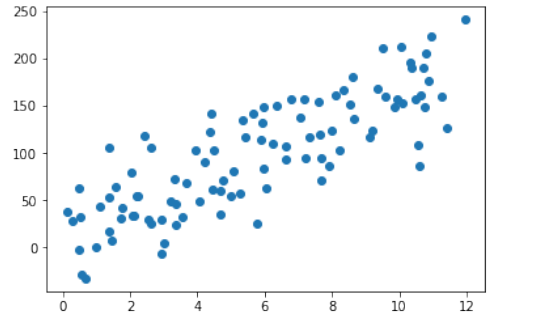

$$
\{(x_i, y_i), i = 1, \ldots, n\}, \qquad n = 100.
$$

Assume that the $x_i$ values are known constants, while the $Y_i$ values satisfy

$$
Y_i = f(x_i) + \varepsilon_i,
$$

where the $\varepsilon_i$ values are independent and identically distributed with $E[\varepsilon_i] = 0$ and $V[\varepsilon_i] = \sigma^2$. We consider two possible models:

$$
\begin{aligned}
f(x) &= \beta_0 + \beta_1 x &&\text{Model 1},\\
f(x) &= \gamma_1 x &&\text{Model 2}.
\end{aligned}
$$

For Model 1, the least squares estimators are

$$
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}, \qquad
\hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}.
$$

You do not need to show this.

### (a)

For Model 2, show that the least squares estimate of $\gamma_1$ is

$$
\hat{\gamma}_1 = \frac{\sum_{i=1}^n x_i y_i}{\sum_{i=1}^n x_i^2}.
$$

<span style="color: green;">**Possible solution:**</span>

Under Model 2, the fitted value is $\hat{y}_i = b x_i$. We minimize

$$
g(b) = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n (y_i - b x_i)^2.
$$

Differentiate with respect to $b$:

$$
\frac{\partial}{\partial b} g(b)
= -2\sum_{i=1}^n (y_i - b x_i)x_i
= -2\left(\sum_{i=1}^n x_i y_i - b\sum_{i=1}^n x_i^2\right).
$$

Setting this derivative equal to zero gives

$$
\boxed{\hat{\gamma}_1 = \frac{\sum_{i=1}^n x_i y_i}{\sum_{i=1}^n x_i^2}}.
$$

### (b)

Compute the expectation of $\hat{\gamma}_1$ under the assumption that Model 2 is correct. Also compute the variance of $\hat{\gamma}_1$, again under the assumption that Model 2 is correct. How can this be used to estimate the standard error of $\hat{\gamma}_1$?

<span style="color: green;">**Possible solution:**</span>

Under Model 2, $Y_i = \gamma_1 x_i + \varepsilon_i$. Therefore,

$$
E[\hat{\gamma}_1]
= E\left[\frac{\sum_{i=1}^n x_iY_i}{\sum_{i=1}^n x_i^2}\right]
= \frac{\sum_{i=1}^n x_i E[Y_i]}{\sum_{i=1}^n x_i^2}
= \frac{\sum_{i=1}^n x_i\gamma_1 x_i}{\sum_{i=1}^n x_i^2}
= \gamma_1.
$$

Thus $\hat{\gamma}_1$ is unbiased when Model 2 is correct. Since the errors are independent,

$$
V[\hat{\gamma}_1]
= V\left[\frac{\sum_{i=1}^n x_iY_i}{\sum_{i=1}^n x_i^2}\right]
= \frac{\sum_{i=1}^n x_i^2\sigma^2}{\left(\sum_{i=1}^n x_i^2\right)^2}
= \frac{\sigma^2}{\sum_{i=1}^n x_i^2}.
$$

By replacing $\sigma$ with an estimate $\hat{\sigma}$, we estimate the standard error by

$$
\widehat{\mathrm{SE}}(\hat{\gamma}_1)
= \sqrt{\frac{\hat{\sigma}^2}{\sum_{i=1}^n x_i^2}}
= \frac{\hat{\sigma}}{\sqrt{\sum_{i=1}^n x_i^2}}.
$$

### (c)

The table below gives estimates for $\beta_0$, $\beta_1$, and $\gamma_1$ based on the data. Estimated standard errors are given using the same type of argument as in the previous subproblem.

| Parameter | Estimate | Standard error |
|---|---:|---:|
| $\beta_0$ | 12.064 | 6.801 |
| $\beta_1$ | 14.895 | 1.022 |
| $\gamma_1$ | 16.460 | 0.522 |

Assume that all three estimators are approximately normally distributed.
- Compare the two models: state an interpretation of the two models' coeffcients in your own words. What does the estimates in the table actually mean? 
- Construct 95% confidence intervals for the three parameters. Based on the confidence intervals, which model would you choose? Hint: the 95% quantiles of the normal dist. is 1.96.
- In general, what could be the consequences of including covariates that are not significant in a regression model? Describe it with your own words.

<span style="color: green;">**Possible solution:**</span>

Using the general form

$$
\hat{\theta} \pm z_{\alpha/2}\hat{\sigma}_{\hat{\theta}},
$$

with $z_{\alpha/2} \approx 1.96$ for 95% confidence intervals, we get

| Parameter | Lower | Upper |
|---|---:|---:|
| $\beta_0$ | -1.266 | 25.393 |
| $\beta_1$ | 12.891 | 16.898 |
| $\gamma_1$ | 15.437 | 17.483 |

The confidence interval for $\beta_0$ contains 0. Therefore, an intercept of 0 is a plausible value, so Model 2 is not unreasonable here. Based only on these confidence intervals, Model 2 can be chosen as the simpler model.

## Exercise 3)

In Exercise 1, one could think that the mirrored shape of our exponential distribution looked a little similar to the distribution in 1b).

Inspired by this, we now use two simulated distributions and perform permutation tests to assess whether they differ at significance level $\alpha = 0.01$. The data is given to you in the next cell:

In [ ]:
u = rng.random(1000)
dist_1 = 6 * (1 - np.sqrt(1 - u))
dist_2 = rng.exponential(2, 1000)

In [ ]:
plt.hist(dist_1, bins=30, density=True, edgecolor="black")
plt.show()

In [ ]:
plt.hist(dist_2, bins=30, density=True, edgecolor="black")
plt.show()

- Write code to perform a permutation test on the mean and median of the distributions to assess whether we reject our $H_0$, and state your conclusion.
- Explain why it might be a good idea to test multiple statistics, like here, when you are to conclude on whether two samples come from the same distribution.

<span style="color: green;">**Possible solution:**</span>


In [ ]:
def permutation_test_mean(x, y, n_perm=10000, random_state=None):
    """
    Permutation test for two independent samples x, y.
    Test statistic: difference in sample means (mean(x) - mean(y)).
    Two-sided test under the null of same distribution.
    """
    rng = np.random.default_rng(random_state)

    x = np.asarray(x)
    y = np.asarray(y)

    # Observed statistic
    obs_stat = x.mean() - y.mean()

    # Pool data
    pooled = np.concatenate([x, y])
    n_x = len(x)

    # Permutations
    perm_stats = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)                 # in-place shuffle
        x_perm = pooled[:n_x]
        y_perm = pooled[n_x:]
        perm_stats[i] = x_perm.mean() - y_perm.mean()

    # Two-sided p-value
    p_value = np.mean(np.abs(perm_stats) >= np.abs(obs_stat))
    return obs_stat, p_value


def permutation_test_median(x, y, n_perm=10000, random_state=None):
    """
    Permutation test for two independent samples x, y.
    Test statistic: difference in sample medians (median(x) - median(y)).
    Two-sided test under the null of same distribution.
    """
    rng = np.random.default_rng(random_state)

    x = np.asarray(x)
    y = np.asarray(y)

    # Observed statistic
    obs_stat = np.median(x) - np.median(y)

    # Pool data
    pooled = np.concatenate([x, y])
    n_x = len(x)

    # Permutations
    perm_stats = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)                 # in-place shuffle
        x_perm = pooled[:n_x]
        y_perm = pooled[n_x:]
        perm_stats[i] = np.median(x_perm) - np.median(y_perm)

    # Two-sided p-value
    p_value = np.mean(np.abs(perm_stats) >= np.abs(obs_stat))
    return obs_stat, p_value

print("Permutation test for means:")
obs_stat_mean, p_value_mean = permutation_test_mean(dist_1, dist_2, n_perm=10000, random_state=1050)
print(f"Observed difference in means: {obs_stat_mean:.4f}, p-value: {p_value_mean:.4f}")

print("Permutation test for medians:")
obs_stat_median, p_value_median = permutation_test_median(dist_1, dist_2, n_perm=10000, random_state=1050)
print(f"Observed difference in medians: {obs_stat_median:.4f}, p-value: {p_value_median:.4f}")

We here see that we have the need for both tests, as the means are not that different. In conclusion, we could use that one statistic is rejected to argue for rejection overall of our $H_0$ of the two distributions being similar.

The test showed us how we might always benefit, depending on our "computation budget", to test for many diferent aspects of the distribution to properly assess their similarity.